# K-means clustering và ứng dụng

Notebook gồm hai phần:

-Phần A: tự cài đặt thuật toán K-means bằng NumPy.

-Phần B: áp dụng thuật toán lên dữ liệu Mall Customers, chọn số cụm bằng elbow method và diễn giải ý nghĩa kinh doanh.

Thuật toán phân cụm chỉ dùng hai đặc trưng: Annual Income (k$) và Spending Score (1-100) để sát với code tự viết nhất (2 feature trong mặt phẳng và dễ minh họa).

In [5]:
#Import các thư viện
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Đặt seed cho notebook để đảm bảo khả năng tái tạo của kết quả.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Phần A - Cài đặt K-means from scratch



In [9]:
def find_closest_centroids(X, centroids):
    #Input: X là mảng (m,n) (m điểm dữ liệu, n đặc trưng)
    #       centroids là mảng (k,n) (k điểm centroids, n đặc trưng)
    #Output: danh sách chỉ số (1,m) thể hiện điểm dữ liệu i gần nhất với centroids
    # thứ mấy?
    m = X.shape[0]  # Số lượng điểm dữ liệu
    K = centroids.shape[0]  # Số lượng tâm cụm
    idx = np.zeros(m, dtype=int)

    for i in range(m):
        #Với mỗi điểm X[i], tính khoảng cách đến từng điểm trong tất cả K tâm cụm
        distances = []
        for k in range(K):
            # Khoảng cách Euclid bình phương, ko cần lấy căn: sum((x1-x2)^2)
            norm = np.sum((X[i] - centroids[k]) ** 2)
            distances.append(norm)

        # Lưu lại chỉ số của tâm cụm gần nhất trong mảng kc tới các tâm cụm.
        idx[i] = np.argmin(distances)

    return idx

def compute_centroids(X, idx, K):
    #Input: danh sách các điểm dữ liệu X, mỗi điểm gần với tâm cụm thứ idx, mảng tâm cụm cũ.
    #Output: tính toán lại mảng tâm cụm mới.
    centroids = []

    for k in range(K): #Xét mỗi tâm cụm và các điểm trong tâm cụm:
        points_in_cluster = X[idx == k]
        #Nếu số lượng điểm nằm trong cụm khác 0 thì cập nhật lại tâm cụm bằng mean
        #của các điểm dữ liệu trong cụm đó.
        if len(points_in_cluster) > 0:
            centroids.append(points_in_cluster.mean(axis=0))
        else:
            #Nếu cụm không có điểm dữ liệu nào, reset cho nó về gốc tọa độ để tránh lỗi numpy
            centroids.append(np.zeros(X.shape[1]))

    return np.array(centroids)

def compute_cost(X, idx, centroids):
    #Tính trung bình bình phương khoảng cách từ mỗi điểm đến tâm cụm.
    squared_distances = np.sum((X - centroids[idx]) ** 2, axis=1)
    return squared_distances.mean()

def run_kmeans(X, initial_centroids, max_iters):
    #Chạy K-means và trả về tâm cụm, nhãn cụm, lịch sử cost.
    centroids = initial_centroids.copy()
    K = len(centroids)
    cost_history = []

    for _ in range(max_iters):
        idx = find_closest_centroids(X, centroids)
        centroids = compute_centroids(X, idx, K)
        cost_history.append(compute_cost(X, idx, centroids))

    idx = find_closest_centroids(X, centroids)
    return centroids, idx, cost_history

## Phần B - Ứng dụng phân khúc khách hàng

### 1. Upload dữ liệu

Trên Google Colab, chạy ô dưới đây rồi chọn file Mall_Customers.csv tải từ Kaggle.

In [6]:
try:
    from google.colab import files

    uploaded = files.upload()
    file_name = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
except ImportError:
    df = pd.read_csv("Mall_Customers.csv")

print("Kích thước dữ liệu:", df.shape)
df.head()

Saving Mall_Customers.csv to Mall_Customers (1).csv
Kích thước dữ liệu: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 2. Khám phá và chuẩn bị dữ liệu

Hai cột được dùng có đơn vị và thang đo khác nhau. Ta chuẩn hóa mỗi cột về trung bình 0 và độ lệch chuẩn 1 để cả thu nhập lẫn điểm chi tiêu đều có ảnh hưởng công bằng lên khoảng cách. Khi trực quan hóa và báo cáo, dữ liệu gốc vẫn được giữ nguyên để dễ hiểu.

In [18]:
FEATURES = ["Annual Income (k$)", "Spending Score (1-100)"]

print(df[FEATURES].dtypes)
print("Số giá trị thiếu:\n", df[FEATURES].isna().sum())
print("Số giá trị vô hạn:", np.isinf(df[FEATURES].to_numpy()).sum())
df[FEATURES].describe().round(2)

Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object
Số giá trị thiếu:
 Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Số giá trị vô hạn: 0


,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00
mean,60.56,50.20
std,26.26,25.82
min,15.00,1.00
25%,41.50,34.75
50%,61.50,50.00
75%,78.00,73.00
max,137.00,99.00


In [20]:
X_original = df[FEATURES].to_numpy(dtype=float)
feature_mean = X_original.mean(axis=0)
feature_std = X_original.std(axis=0)
X = (X_original - feature_mean) / feature_std

print("Shape của X:", X.shape)
print("Trung bình sau chuẩn hóa:", X.mean(axis=0).round(3))
print("Độ lệch chuẩn sau chuẩn hóa:", X.std(axis=0).round(3))

Shape của X: (200, 2)
Trung bình sau chuẩn hóa: [-0. -0.]
Độ lệch chuẩn sau chuẩn hóa: [1. 1.]


### 3. Elbow method

Với mỗi giá trị K, ta chọn ngẫu nhiên K khách hàng làm tâm ban đầu rồi chạy K-means. Cost luôn giảm khi tăng số cụm; điểm cần tìm là nơi mức giảm bắt đầu chậm lại rõ rệt, tạo thành hình khuỷu tay. Seed cố định giúp kết quả có thể tái lập.

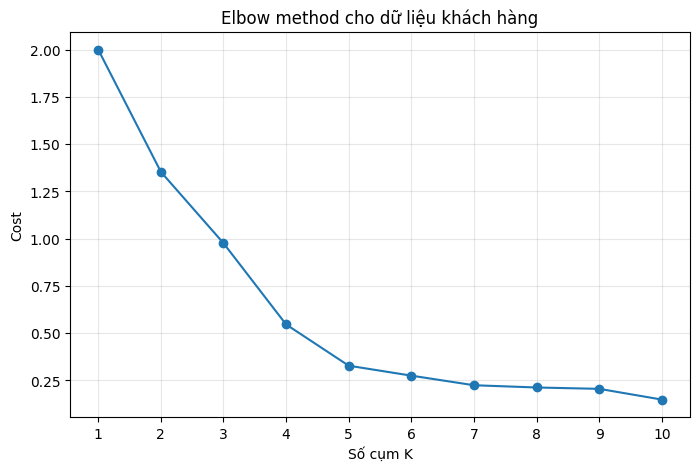

,K,Cost
0,1,2.0000
1,2,1.3535
2,3,0.9762
3,4,0.5461
4,5,0.3279
5,6,0.2753
6,7,0.2246
7,8,0.2126
8,9,0.2055
9,10,0.1487


In [23]:
def initialize_centroids(X, K, random_seed=RANDOM_SEED):
    rng = np.random.default_rng(random_seed)
    chosen_rows = rng.choice(len(X), size=K, replace=False)
    return X[chosen_rows].copy()


K_values = range(1, 11)
costs = []

for K in K_values:
    initial_centroids = initialize_centroids(X, K)
    centroids, idx, _ = run_kmeans(X, initial_centroids, max_iters=100)
    costs.append(compute_cost(X, idx, centroids))

plt.figure(figsize=(8, 5))
plt.plot(K_values, costs, marker="o")
plt.xticks(list(K_values))
plt.xlabel("Số cụm K")
plt.ylabel("Cost")
plt.title("Elbow method cho dữ liệu khách hàng")
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({"K": list(K_values), "Cost": costs}).round(4)

Đường cong giảm mạnh đến khoảng K = 5, sau đó lợi ích của việc thêm cụm nhỏ dần. Vì vậy ta chọn 5 cụm

### 4. Huấn luyện mô hình cuối cùng và trực quan hóa

In [25]:
K_CHOSEN = 5
initial_centroids = initialize_centroids(X, K_CHOSEN)
centroids_scaled, cluster_labels, cost_history = run_kmeans(
    X, initial_centroids, max_iters=100
)

centroids_original = centroids_scaled * feature_std + feature_mean #Khôi phục lại các tâm cụm ở thang đo ban đầu.
df_result = df.copy()
df_result["Cluster"] = cluster_labels

print("Cost cuối cùng:", round(cost_history[-1], 4))
print("Số khách hàng mỗi cụm:\n", df_result["Cluster"].value_counts().sort_index())

Cost cuối cùng: 0.3279
Số khách hàng mỗi cụm:
 Cluster
0    36
1    23
2    39
3    22
4    80
Name: count, dtype: int64


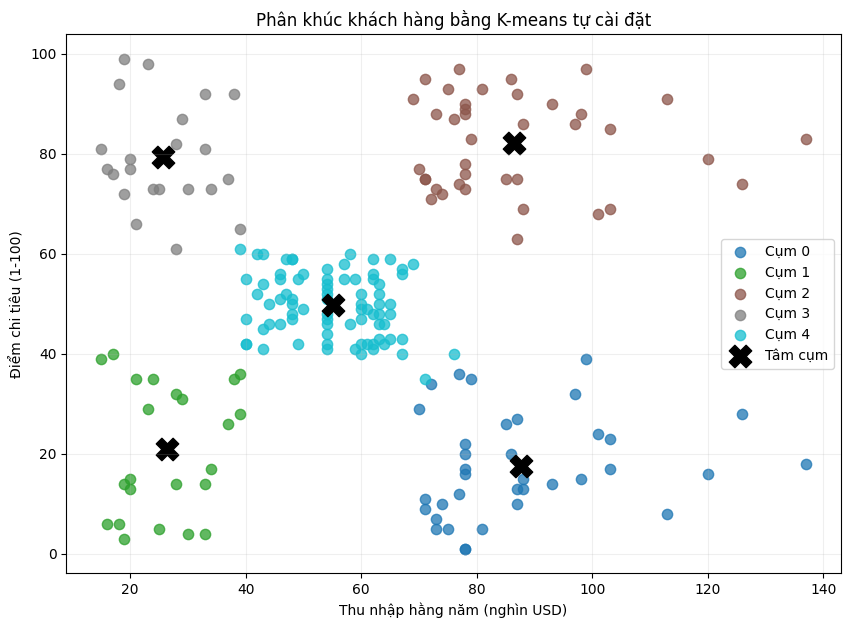

In [26]:
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, K_CHOSEN))

for k, color in enumerate(colors):
    points = X_original[cluster_labels == k]
    plt.scatter(points[:, 0], points[:, 1], s=55, alpha=0.75, color=color, label=f"Cụm {k}")

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    marker="X",
    s=260,
    c="black",
    label="Tâm cụm",
)
plt.xlabel("Thu nhập hằng năm (nghìn USD)")
plt.ylabel("Điểm chi tiêu (1-100)")
plt.title("Phân khúc khách hàng bằng K-means tự cài đặt")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

5. Ý nghĩa kinh doanh.

Dựa vào biểu đồ minh họa, có thể nêu ra ý nghĩa của các cụm:

Cụm 0: Thu nhập trung bình - cao, nhưng chi tiêu trung bình - ít.

Cụm 1: Thu nhập trung bình - thấp, chi tiêu trung bình - thấp.

Cụm 2: Thu nhập trung bình - cao, chi tiêu trung bình - cao.

Cụm 3: Thu nhập trung bình - thấp, nhưng chi tiêu trung bình - cao.

Cụm 4: Thu nhập trung bình, chi tiêu trung bình luôn.